In [3]:
from datetime import datetime
import os
from pathlib import Path
import pickle
import sys
import traceback

import interfere.methods
import interfere_experiments as ie
import numpy as np
import optuna

# Collect script arguments
DATA_FILE = "/Users/djpassey/Google Drive/My Drive/Docs/PhD Research/DissertationColabs/InterfereBenchmark1.1.1/LowStochastic/AttractingFixedPoint4D.json" #sys.argv[1]

METHOD_GROUP = "FAST"
if len(sys.argv) > 2:
    METHOD_GROUP = sys.argv[2]


SAVE_DIR = "/tmp/" #"/work/users/d/j/djpassey/interfere_exp13.1/"
ALL_METHODS = [
    interfere.methods.AverageMethod,
    interfere.methods.VAR,
    interfere.methods.SINDY,
    interfere.methods.ResComp,
    interfere.methods.LSTM,
    interfere.methods.NHITS,
]
FAST_METHODS = [
    interfere.methods.AverageMethod,
    interfere.methods.VAR,
    interfere.methods.SINDY,
    interfere.methods.ResComp,
]

METHOD_GROUPS = {
    None: ALL_METHODS,
    "FAST": FAST_METHODS,
    "ARIMA": [interfere.methods.ARIMA],
    "NHITS": [interfere.methods.NHITS],
    "LSTM": [interfere.methods.LSTM]
}

METHODS = METHOD_GROUPS[METHOD_GROUP]

OPTUNA_TRIALS_DICT = {
    interfere.methods.AverageMethod: 1,
    interfere.methods.VAR: 2, #51,
    interfere.methods.SINDY: 2, #101,
    interfere.methods.ResComp: 2, #201,
    interfere.methods.ARIMA: 2, #51,
    interfere.methods.NHITS: 2, #101,
    interfere.methods.LSTM: 2, #101,
}

TRAIN_WINDOW_PERCENT = 0.5
NUM_FOLDS = 3
NUM_VAL_PRIOR_STATES = 25
RMSE = lambda _, target, prediction, *args : interfere.metrics.rmse(
    target, prediction)
NUM_TRAIN_OBS_LIST = [100]#, 200, 500, 1000, 2000, 3000, 4000, 5000]

# For debugging.
RAISE_EXCEPTIONS = True

data_name = os.path.basename(DATA_FILE).split(".")[0]
STOCH_DATA = ie.control_vs_resp.load_cvr_json(DATA_FILE)

f = Path(DATA_FILE)
stoch_level = f.parent

deterministic_data_file = f.parent.with_name("Deterministic") / f.name

DETERM_DATA = ie.control_vs_resp.load_cvr_json(deterministic_data_file)
TARGET_IDX = DETERM_DATA.target_idx

assert isinstance(TARGET_IDX, int), (
    f"TARGET_IDX is not an integer: TARGET_IDX = {TARGET_IDX}")


score_file = SAVE_DIR + data_name + f"_scores[{str(METHOD_GROUP)}].pkl"
pred_file = SAVE_DIR + data_name + f"_preds[{str(METHOD_GROUP)}].pkl"

# Initialize empty results dictionaries
score_df_cols = [
     "Dynamics", "Method", "Obs", "ForecastError", "CausalError", 
     "Noise", "Duration", "Trials", "Size", "Exceptions"
]
score_array = []

predictions = {
    m.__name__: {
        obs: {
            "forecast_pred": None,
            "causal_pred": None,
            "train_pred": None
        } for obs in NUM_TRAIN_OBS_LIST
    } for m in METHODS
}

try:
    # Main experiment loop.
    for method_type in METHODS:
        for num_train_obs in NUM_TRAIN_OBS_LIST:

            errors = ""
            start_time = datetime.now()

            # Take the train data prior to the forecast.
            stoch_train_states = STOCH_DATA.train_states[-num_train_obs:]
            stoch_train_times = STOCH_DATA.train_t[-num_train_obs:]

            # Build a cross validation objective to optimize.
            objv = interfere.cross_validation.CrossValObjective(
                method_type,
                stoch_train_states,
                stoch_train_times,
                TRAIN_WINDOW_PERCENT,
                NUM_FOLDS,
                val_scheme="forecast",
                num_val_prior_states=NUM_VAL_PRIOR_STATES,
                metric=RMSE,
                store_preds=True,
                raise_errors=RAISE_EXCEPTIONS,
                exog_idxs=STOCH_DATA.do_intervention.intervened_idxs,
            )

            study = optuna.create_study(
                study_name=(
                    method_type.__name__ + " on " + str(stoch_level.name) + " " + data_name + 
                    f"({num_train_obs})"
                )
            )
            n_trials = OPTUNA_TRIALS_DICT[method_type]
            study.optimize(objv, n_trials=n_trials)

            # Try scoring the best method on deterministic data.
            try:
                best_params = study.best_params

                # Fit to STOCHASTIC data.
                obs_method = method_type(**best_params)
                obs_method.fit(
                    stoch_train_times, 
                    *STOCH_DATA.obs_intervention.split_exog(
                        stoch_train_states)
                )

                # Forecast the DETERMINISTIC data. 
                forecast_pred = obs_method.simulate(
                    DETERM_DATA.forecast_t,
                    prior_states=DETERM_DATA.train_states,
                    prior_t=DETERM_DATA.train_t,
                    intervention=DETERM_DATA.obs_intervention,
                )

                # Forecast error.
                fcast_error = RMSE(
                    None,
                    DETERM_DATA.forecast_states[:, [TARGET_IDX]],
                    forecast_pred[:, [TARGET_IDX]],
                    None,
                )

            except Exception as e:
                fcast_error = np.nan
                forecast_pred = None
                errors += f"\n\nERROR {e}" + str(traceback.format_exc())

                if RAISE_EXCEPTIONS:
                    raise e


            # Causal prediction.
            try:
                best_params = study.best_params

                do_method = method_type(**best_params)
                do_method.fit(
                    stoch_train_times, 
                    *STOCH_DATA.do_intervention.split_exog(stoch_train_states)
                )


                causal_pred = do_method.simulate(
                    DETERM_DATA.forecast_t,
                    prior_states=DETERM_DATA.train_states,
                    prior_t=DETERM_DATA.train_t,
                    intervention=DETERM_DATA.do_intervention,
                )

                # Causal prediction error.
                causal_error = RMSE(
                    None,
                    DETERM_DATA.interv_states[:, [TARGET_IDX]],
                    causal_pred[:, [TARGET_IDX]],
                    None
                )

            except Exception as e:
                causal_error = np.nan
                causal_pred = None
                errors += f"\n\nERROR {e}" + str(traceback.format_exc())

                if RAISE_EXCEPTIONS:
                    raise e
            
            try:
                best_trial_idx = study.best_trial.number
            except ValueError as e:
                print(
                    "Error finding best trial: "
                    f"\n\n{e}\n\n{traceback.format_exc()}"
                )
                best_trial_idx = 0

                if RAISE_EXCEPTIONS:
                    raise e

            end_time = datetime.now()
            duration = str(end_time - start_time)
            pred_sz = len(pickle.dumps(objv.trial_results[best_trial_idx]))

            # Save scores.
            score_array.append([
                data_name, method_type.__name__, num_train_obs, fcast_error, causal_error, stoch_level.name,
                duration, n_trials, pred_sz, errors
            ])

            # Save predictions.
            predictions[method_type.__name__][num_train_obs][
                "train_pred"] = objv.trial_results[best_trial_idx]
            predictions[method_type.__name__][num_train_obs][
                "forecast_pred"] = forecast_pred
            predictions[method_type.__name__][num_train_obs][
                "causal_pred"] = causal_pred
            
            with open(score_file, "wb") as sf:
                pickle.dump(
                    {"cols": score_df_cols, "score_array": score_array}, sf)
                
            with open(pred_file, "wb") as pf:
                pickle.dump(predictions, pf)

except Exception as e:
    print("Experiment ended because of exception.")
    print(type(e).__name__, ": ", e)
    print(traceback.format_exc())

    if RAISE_EXCEPTIONS:
        raise e

[I 2025-04-16 14:00:04,885] A new study created in memory with name: AverageMethod on LowStochastic AttractingFixedPoint4D(100)
[I 2025-04-16 14:00:04,918] Trial 0 finished with value: 0.013929911595520905 and parameters: {}. Best is trial 0 with value: 0.013929911595520905.
[I 2025-04-16 14:00:04,999] A new study created in memory with name: VAR on LowStochastic AttractingFixedPoint4D(100)
[I 2025-04-16 14:00:05,107] Trial 0 finished with value: 152.6743209881908 and parameters: {'ic': 'fpe', 'maxlags': 17, 'trend': 'ctt'}. Best is trial 0 with value: 152.6743209881908.
[I 2025-04-16 14:00:05,135] Trial 1 finished with value: 83.05950037359149 and parameters: {'ic': 'fpe', 'maxlags': 18, 'trend': 'c'}. Best is trial 1 with value: 83.05950037359149.
[I 2025-04-16 14:00:05,216] A new study created in memory with name: SINDY on LowStochastic AttractingFixedPoint4D(100)
/Users/djpassey/Code/interfere/venv_interfere/lib/python3.9/site-packages/pysindy/optimizers/stlsq.py:191: UserWarning: 

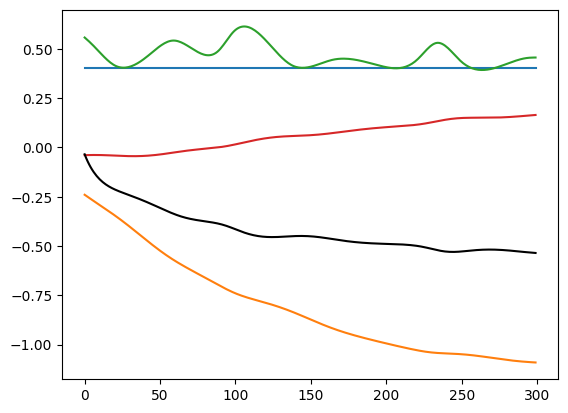

In [14]:
import matplotlib.pyplot as plt
plt.plot(predictions["ResComp"][100]["causal_pred"])
plt.plot(target_cvr_data.interv_states[:, TARGET_IDX], c="k")

In [10]:
import pandas as pd
df = pd.DataFrame(score_array, columns=score_df_cols)
df

,Dynamics,Method,Obs,ForecastError,CausalError,Noise,Duration,Trials,Size,Exceptions
0,AttractingFixedPoint4D,AverageMethod,100,0.024453,0.399103,LowStochastic,0:00:00.217090,1,7893,
1,AttractingFixedPoint4D,VAR,100,0.317809,1.136799,LowStochastic,0:00:00.474067,5,7893,
2,AttractingFixedPoint4D,SINDY,100,0.021816,0.401839,LowStochastic,0:00:02.413679,5,7893,
3,AttractingFixedPoint4D,ResComp,100,0.224724,2.204348,LowStochastic,0:00:03.090985,5,7893,
4,AttractingFixedPoint4D,LSTM,100,0.034764,0.347524,LowStochastic,0:10:25.014091,2,7893,
5,AttractingFixedPoint4D,NHITS,100,32.365483,11.972252,LowStochastic,0:16:02.423897,2,7893,
